In [2]:
import os
from glob import glob
from PIL import Image
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import random
import torch


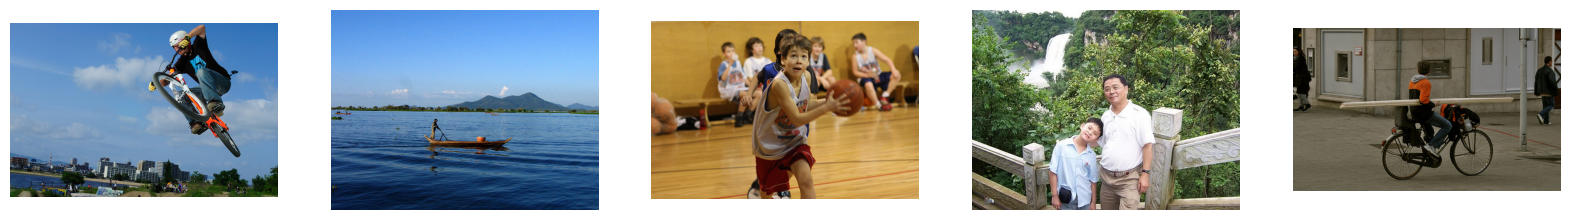

In [3]:
# Đường dẫn đến thư mục chứa ảnh
image_folder = '' #Đường dẫn dataset

# Lấy danh sách file ảnh
image_files = glob(os.path.join(image_folder, "*.jpg"))

# Hiển thị thử 5 ảnh ngẫu nhiên
selected_files = random.sample(image_files, 5)
plt.figure(figsize=(20, 5))

for i, file in enumerate(selected_files):
    image = Image.open(file)
    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.axis("off")

plt.show()


In [5]:
import time
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Sử dụng thiết bị: {device}")

# Tải mô hình SentenceTransformer
model = SentenceTransformer('clip-ViT-B-32', device=device)

# Chia nhỏ dữ liệu để tính embeddings
chunk_size = 256
embeddings = []

def process_chunk(chunk):
    images = [Image.open(image_file) for image_file in chunk]
    chunk_embeddings = model.encode(images)
    return chunk_embeddings

# Đo thời gian toàn bộ quá trình
total_start_time = time.time()

# Tính embeddings cho toàn bộ ảnh
for i in range(0, len(image_files), chunk_size):
    chunk_start_time = time.time()
    
    print(f"Processing chunk {i} / {len(image_files)}")
    chunk = image_files[i:i + chunk_size]
    embeddings.extend(process_chunk(chunk))
    
    chunk_end_time = time.time()
    elapsed_chunk_time = chunk_end_time - chunk_start_time
    print(f"⏳ Thời gian xử lý chunk {i // chunk_size + 1}: {elapsed_chunk_time:.2f} giây\n")

# Đo tổng thời gian
total_end_time = time.time()
elapsed_total_time = total_end_time - total_start_time
print(f"✅ Hoàn thành tính toán embeddings. Tổng thời gian: {elapsed_total_time:.2f} giây")


Sử dụng thiết bị: cuda
Processing chunk 0 / 31783


C:\Users\NamNamNam\anaconda3\envs\translate\Lib\site-packages\transformers\models\clip\modeling_clip.py:539: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


⏳ Thời gian xử lý chunk 1: 12.64 giây

Processing chunk 256 / 31783
⏳ Thời gian xử lý chunk 2: 12.70 giây

Processing chunk 512 / 31783
⏳ Thời gian xử lý chunk 3: 13.28 giây

Processing chunk 768 / 31783
⏳ Thời gian xử lý chunk 4: 12.47 giây

Processing chunk 1024 / 31783
⏳ Thời gian xử lý chunk 5: 10.95 giây

Processing chunk 1280 / 31783
⏳ Thời gian xử lý chunk 6: 12.84 giây

Processing chunk 1536 / 31783
⏳ Thời gian xử lý chunk 7: 12.79 giây

Processing chunk 1792 / 31783
⏳ Thời gian xử lý chunk 8: 12.59 giây

Processing chunk 2048 / 31783
⏳ Thời gian xử lý chunk 9: 15.76 giây

Processing chunk 2304 / 31783
⏳ Thời gian xử lý chunk 10: 10.61 giây

Processing chunk 2560 / 31783
⏳ Thời gian xử lý chunk 11: 13.81 giây

Processing chunk 2816 / 31783
⏳ Thời gian xử lý chunk 12: 15.79 giây

Processing chunk 3072 / 31783
⏳ Thời gian xử lý chunk 13: 20.40 giây

Processing chunk 3328 / 31783
⏳ Thời gian xử lý chunk 14: 10.54 giây

Processing chunk 3584 / 31783
⏳ Thời gian xử lý chunk 15: 14.4

In [6]:
# Tạo FAISS index
dimension = len(embeddings[0])
index = faiss.IndexFlatIP(dimension)
index = faiss.IndexIDMap(index)

vectors = np.array(embeddings).astype('float32')
index.add_with_ids(vectors, np.array(range(len(embeddings))))

# Lưu FAISS index
faiss.write_index(index, "index.faiss")

# Lưu danh sách file ảnh
with open("image_files.txt", "w") as f:
    for image_file in image_files:
        f.write(image_file + "\n")


In [7]:
# Lưu mô hình đã tải
model.save("saved_model")


In [8]:
def search_image(query, model, index, image_files, top_k=5):
    if query.endswith(".jpg"):
        query = Image.open(query)

    query_embedding = model.encode(query)
    query_embedding = query_embedding.astype("float32").reshape(1, -1)

    distances, indices = index.search(query_embedding, top_k)
    retrieved_image_files = [image_files[i] for i in indices[0]]
    return query, retrieved_image_files


In [10]:
def visualize_results(query, retrieved_images):
    plt.figure(figsize=(12, 5))

    # If image query
    if isinstance(query, Image.Image):
        plt.subplot(1, len(retrieved_images) + 1, 1)
        plt.imshow(query)
        plt.title("Query Image")
        plt.axis('off')
        start_idx = 2

    # If text query
    else:
        plt.subplot(1, len(retrieved_images) + 1, 1)
        plt.text(0.5, 0.5, f"Query:\n\n '{query}'", fontsize=16, ha='center', va='center')
        plt.axis('off')
        start_idx = 2

    # Display images
    for i, img_path in enumerate(retrieved_images):

        plt.subplot(1, len(retrieved_images) + 1, i + start_idx)
        plt.imshow(Image.open(img_path))
        plt.title(f"Match {i + 1}")
        plt.axis('off')

    plt.show()

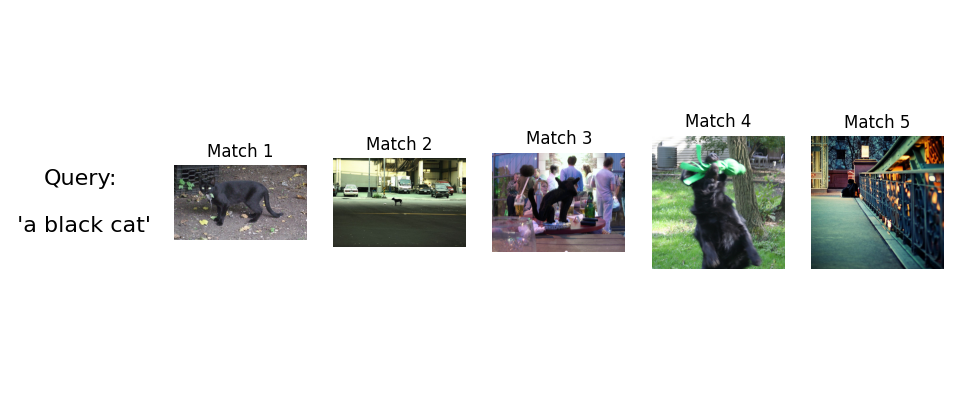

In [15]:
# Truy vấn tìm kiếm bằng văn bản
query = "a black cat"  # Thay đổi câu truy vấn tại đây
query, retrieved_image_files = search_image(query, model, index, image_files)
visualize_results(query, retrieved_image_files)


In [12]:
# Load lại FAISS index
index = faiss.read_index("index.faiss")

# Load lại danh sách file ảnh
with open("image_files.txt", "r") as f:
    image_files = [line.strip() for line in f]

# Load lại mô hình
model = SentenceTransformer("saved_model")
